# Testes para homogeneidade de variâncias

Uma das condições para se aplicar um teste paramétrico para comparação de $k$ médias populacionais é que as variâncias das populações, estimadas a partir de $k$ amostras representativas, sejam homogêneas ou iguais.

Na hipótese nula dos testes de homogeneidade de variância, as variâncias das $k$ populações são homogêneas. Na hipótese alternativa, pelo menos uma variância populacional é diferente das demais.

$$
H_0: \sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2
$$

$$
H_1: \exists_{i,j}: \sigma_i^2 \neq \sigma_j^2 (i, j = 1, \cdots, k)
$$

## Teste de Levene

O teste de Levene é pouco sensível a desvios de normalidade, sendo bastante utilizado para teste de homogeneidade de variâncias.

Uma rede de supermercados deseja estudar o número de clientes atendidos diariamente em suas lojas para tomar decisões estratégicas de operações. A base de dados a seguir apresenta os dados de três lojas ao longo de duas semanas. Verifique se as variâncias entre os grupos são homogêneas, considerando $\alpha = 5\%$.

In [1]:
import pandas as pd

DADOS_SUPERMERCADO = "./dados/customers_stores.csv"

df_supermercado = pd.read_csv(DADOS_SUPERMERCADO, index_col="Dia")

df_supermercado

,Loja_1,Loja_2,Loja_3
Dia,,,
Dia 1,620,710,924
Dia 2,630,780,695
Dia 3,610,810,854
Dia 4,650,755,802
Dia 5,585,699,931
Dia 6,590,680,924
Dia 7,630,710,847
Dia 8,644,850,800
Dia 9,595,844,769


In [2]:
df_supermercado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, Dia 1 to Dia 14
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Loja_1  14 non-null     int64
 1   Loja_2  14 non-null     int64
 2   Loja_3  14 non-null     int64
dtypes: int64(3)
memory usage: 448.0+ bytes


In [3]:
df_supermercado.describe()

,Loja_1,Loja_2,Loja_3
count,14.000000,14.000000,14.000000
mean,609.428571,737.214286,833.357143
std,24.405908,62.246629,78.914371
min,570.000000,645.000000,695.000000
25%,591.250000,699.750000,776.750000
50%,607.500000,714.000000,850.500000
75%,628.000000,773.750000,897.750000
max,650.000000,850.000000,931.000000


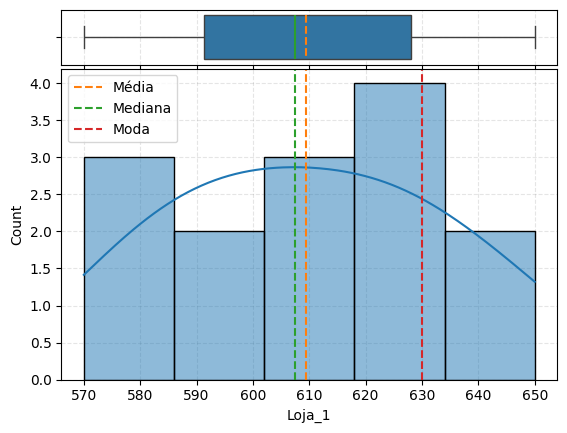

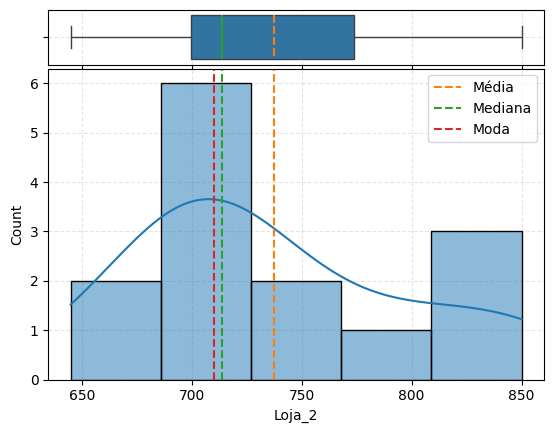

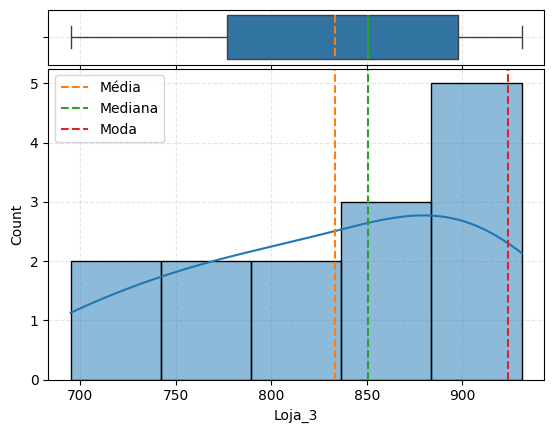

In [4]:
from auxiliares import composicao_histograma

for coluna in df_supermercado.columns:
    composicao_histograma(df_supermercado, coluna)

<Axes: ylabel='Count'>

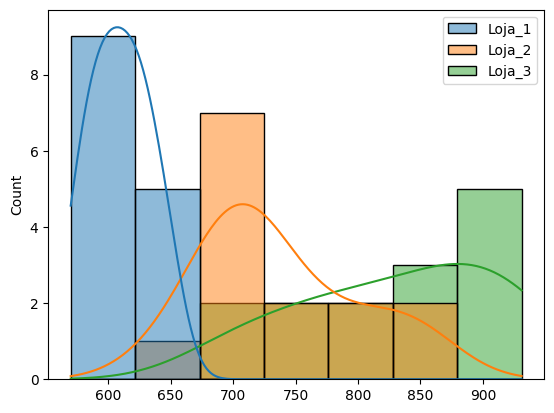

In [5]:
import seaborn as sns

sns.histplot(df_supermercado,kde=True)

<Axes: >

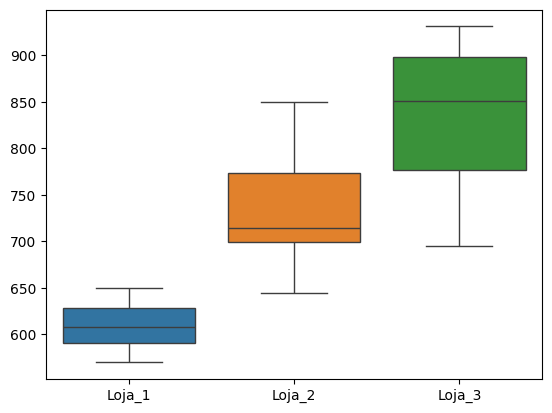

In [6]:
sns.boxplot(data=df_supermercado)

In [7]:
from auxiliares import analise_shapiro, analise_levene, analises_shapiro_levene

analise_shapiro(df_supermercado)

teste de shapiro
 estatistica_sw =0.975
Loja_1 segue uma distribuição normal (valor p: 0.935)
 estatistica_sw =0.917
Loja_2 segue uma distribuição normal (valor p: 0.197)
 estatistica_sw =0.932
Loja_3 segue uma distribuição normal (valor p: 0.322)


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html

In [8]:
from scipy.stats import levene

levene(df_supermercado["Loja_1"],df_supermercado["Loja_2"],df_supermercado["Loja_3"],center ="mean")

LeveneResult(statistic=np.float64(8.426665687474399), pvalue=np.float64(0.0009084535848988536))

In [9]:
levene(*[df_supermercado[coluna] for coluna in df_supermercado.columns],center ="mean")

LeveneResult(statistic=np.float64(8.426665687474399), pvalue=np.float64(0.0009084535848988536))

In [10]:
analise_levene(df_supermercado)

teste de levene
estatistica_levene =8.427
Pelo menos uma variancia é diferente (valor p: 0.001)


In [11]:
analises_shapiro_levene(df_supermercado)

teste de shapiro
 estatistica_sw =0.975
Loja_1 segue uma distribuição normal (valor p: 0.935)
 estatistica_sw =0.917
Loja_2 segue uma distribuição normal (valor p: 0.197)
 estatistica_sw =0.932
Loja_3 segue uma distribuição normal (valor p: 0.322)

teste de levene
estatistica_levene =8.427
Pelo menos uma variancia é diferente (valor p: 0.001)
